# Trabajo Final Aprendizaje Profundo

### Sara Blanco López
### Josep Peiró Ramos

##### Notebook para mostrar resultados
_01/04/2025_

En este cuaderno se van a mostrar los resultados finales obtenidos a partir de realizar el experimento que se ha especificado profundamente en el informe.

Este trabajo ha consistido esencialmente en replicar el experimento realizado en el siguiente artículo: [Data is Overrated: Perceptual Metrics Can Lead Learning in the Absence of Training Data](https://arxiv.org/abs/2312.03455)

Este experimento tenía la intención de mostrar cuales eran los resultados de utilizar métricas de error tradicionales u otras con más sentido semántico perceptual.

Nosotros hemos replicado el experimento de manera prácticamente equivalente a la que realizan los autores y aquí se muestran los resultados de manera clara. Pese a no llegar exactamente a los mismos resultados llegamos a unos que podrían considerarse equivalentes.

En el artículo original comparan el resultado de usar la métrica MSE, que es la que se suele utilizar por defecto; con otras como NLPD (Normalized Laplacian Piramid Distance) y MS-SSIM (Multi-scale Similarity Index Metric). Estas segundas están diseñadas para tener un comportamiento más parecido a reconocer características perceptuales en imágenes, aunque aquí se demuestra que también son aplicables a audios. Estas dos métricas tienen un comportamiento similar aunque no igual. Y en el experimento obtenemos el resultado de que el MS-SIM obtiene un error menor que el NLPD. Esto ocurre al revés en el artículo original sin embargo no nos preocupa ya que realmente se mantiene el el objetivo principal del artículo que era demostrar que utilizar métricas perceptuales es más recomendable para datos que lo requieran.

Mostramos los resultados, primero cargamos los recursos necesarios:

In [ ]:
import requests

for url in (
    "https://raw.githubusercontent.com/JosepPeiro/Perceptual-Metrics-VAE/main/preprocessing.py", # Reconstruction, adapt
    "https://raw.githubusercontent.com/JosepPeiro/Perceptual-Metrics-VAE/main/LoadingDefault.py"): # LoadLossTableGithub, LoadModelGithub, LoadAudiosTestGithub
    codigo = requests.get(url).text
    exec(codigo)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import Audio

import torch
import torch.nn as nn
import torch.nn.functional as F

Ahora vamos a cargar los modelos autoencoder preentrenados. Estos consisten en Modelos Autoencoder con limitación de entropía en la capa intermedia, esta servía para mantenar que el conocimiento que realizaban los autoencoders fuese explícitamente por la métrica que se utilizaba y no por tener un espacio latente diferentemente estructurado que les permitía extraer mejor o peor la información.

En total tenemos 6 modelos, todos con la misma arquitectura, con 4 capas convolucionales en el encoder y 4 capas convolucionales transpuestas y una convolucional en el decoder. Mostramos a modo de visualización su definición.

In [129]:
class EntropyLimitedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.centers = torch.Tensor([-1, 1])
        self.sigma = 10
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=128, kernel_size=3, stride=2, padding=1),  # Reduce tamaño a 128x128
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=2, padding=1),  # Reduce tamaño a 128x128
            nn.BatchNorm2d(128),
            nn.Tanh()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(in_channels=128, out_channels=1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )


    def encode(self, x):
        y = self.encoder(x)
        return y

    
    def quantise(self, y):
        if self.centers is None:
            return y
        y_flat = y.reshape(y.size(0), y.size(1), y.size(2)*y.size(3), 1)
        dist = torch.abs((y_flat - self.centers))**2
        if self.train:
            phi = F.softmax(-self.sigma * dist, dim=-1)
        else:
            phi = F.softmax(-1e7 * dist, dim=-1)
            symbols_hard = torch.argmax(phi, axis=-1)
            phi = F.one_hot(symbols_hard, num_classes=self.centers.size(0))
        inner_product = phi * self.centers
        y_hat = torch.sum(inner_product, axis=-1)
        y_hat = y_hat.reshape(y.shape)
        return y_hat
    

    def decode(self, y):
        x = self.decoder(y)
        return x
    

    def forward(self, x):
        encoded = self.encode(x)
        limit_entropy = self.quantise(encoded)
        decoded = self.decode(limit_entropy)
        return decoded

Vista la arquitectura, cargamos los 6 modelos preentrenados (los pesos). En orden estaremos cargando:
- Modelo entrenado con la métrica **MSE** y datos de **canciones** reales
- Modelo entrenado con la métrica **NLPD** y datos de **canciones** reales
- Modelo entrenado con la métrica **MS-SSIM** y datos de **canciones** reales
- Modelo entrenado con la métrica **MSE** y datos de **ruido**
- Modelo entrenado con la métrica **NLPD** y datos de **ruido**
- Modelo entrenado con la métrica **MS-SSIM** y datos de **ruido**

A continuación también cargamos una porción de los datos (100 muestras) de test para mostrar la reconstrucción de cada modelo.

Los datos han se definen de la siguiente manera. Hemos utilizado archivos de audio de 4.2 segundos. Cada uno, lo hemos descompuesto en su espectograma de Mel y lo hemos cuantizado 256 veces en 256 frecuencias. De esta manera obtenemos imágenes de cada canción de 256 x 256. Por otra parte teníamos un conjunto de datos de ruido que consistía en números aleatorios distribuidos con una un distribución uniforme 0-1 con la misma estructura espacial que los datos primeros.

In [130]:
mse_songs = LoadModelsGithub(EntropyLimitedAutoencoder(), "MSE-songs.pth")
nlpd_songs = LoadModelsGithub(EntropyLimitedAutoencoder(), "NLPD-songs.pth")
msssim_songs = LoadModelsGithub(EntropyLimitedAutoencoder(), "MSSSIM-songs.pth")

mse_noise = LoadModelsGithub(EntropyLimitedAutoencoder(), "MSE-noise.pth")
nlpd_noise = LoadModelsGithub(EntropyLimitedAutoencoder(), "NLPD-noise.pth")
msssim_noise = LoadModelsGithub(EntropyLimitedAutoencoder(), "MSSSIM-noise.pth")

modelos = (mse_songs, nlpd_songs, msssim_songs, mse_noise, nlpd_noise, msssim_noise)
modelos = [modelo.to("cpu").eval() for modelo in modelos]
order_models = ["MSE-SONGS", "NLPD-SONGS", "MSSSIM-SONGS", "MSE-NOISE", "NLPD-NOISE", "MSSSIM-NOISE"]

In [131]:
example, metadata = LoadAudiosTestGithub(limit=100) # Esta instrucción puede llevar un rato, ya que carga los audios de Github
example_adapt = adapt(example)

A continuación vamos a mostrar la gráfica equivalente a la que aparece en el artículo original, y que es el descubrimiento más importante de ese artículo y es una tabla en la que aparece cada métrica de error para cada modelo construido. Es decir para cada uno de los modelos definidos previamente se ha visto el valor que tenía en test con cada una de las tres métricas, es decir: MSE, NLPD y MS-SSIM.

En la izquierda de la gráfica se pueden identificar los modelos entrenados con datos de canciones o con ruido y qué métricas se ha utilizado. Y lo que se encuentra es que a los modelos entrenados con canciones les ocurre que la métrica con menor error es aquella con la que este ha sido entrenado. En cambio, con los modelos entrenados con ruido la mejor métrica siempre corresponde al MS-SIM, seguida a continuación del NLPD, dejando siempre en último lugar al MSE. Y eso muestra que utilizar métricas perceptuales ayuda a obtener unas métricas de error más consistentes.

In [134]:
losses = LoadLossTableGithub()
losses

Test Metric                MSE       NLPD    MSSSIM
Training Data Loss                                 
SONG          MSE     0.001767   4.358403  0.060718
              NLPD    0.002121   3.406427  0.054312
              MSSSIM  0.002496   5.392561  0.024673
NOISE         MSE     0.017674  12.664735  0.259824
              NLPD    0.015393   9.353093  0.251912
              MSSSIM  0.006455   9.240130  0.088304

Invitamos al usuario a que escoja un número aleatorio entre 0 y 100 para ver los resultados de un archivo cualquiera. En los siguientes gráficos podrá observar esa canción original y su reconstrucciones para cada modelo.

In [ ]:
indice_audio = 66 # Se puede cambiar el audio de prueba entre 0 y 99

Aquí se muestra, para un audio (el seleccionado previamente), su espectograma original y qué genera cada modelo por separado. Por lo general no se identifican grandes diferencias en las imágenes de los espectogramas entre los 3 modelos entrenados con canciones, ya que estos son muy complicados de interpretar. Y sin embargo, los modelos que utilizan ruido tienen siempre por lo general una imagen emborronada y con cierta periodicidad, especialmente el de NLPD. Esto podemos hipotecizar que es debido a cómo estos trabaja con convoluciones, se muestra después en el resultado. Es visible que los modelos entrenados con ruido no son capaces de reconstruir la estructura de un audio natural.

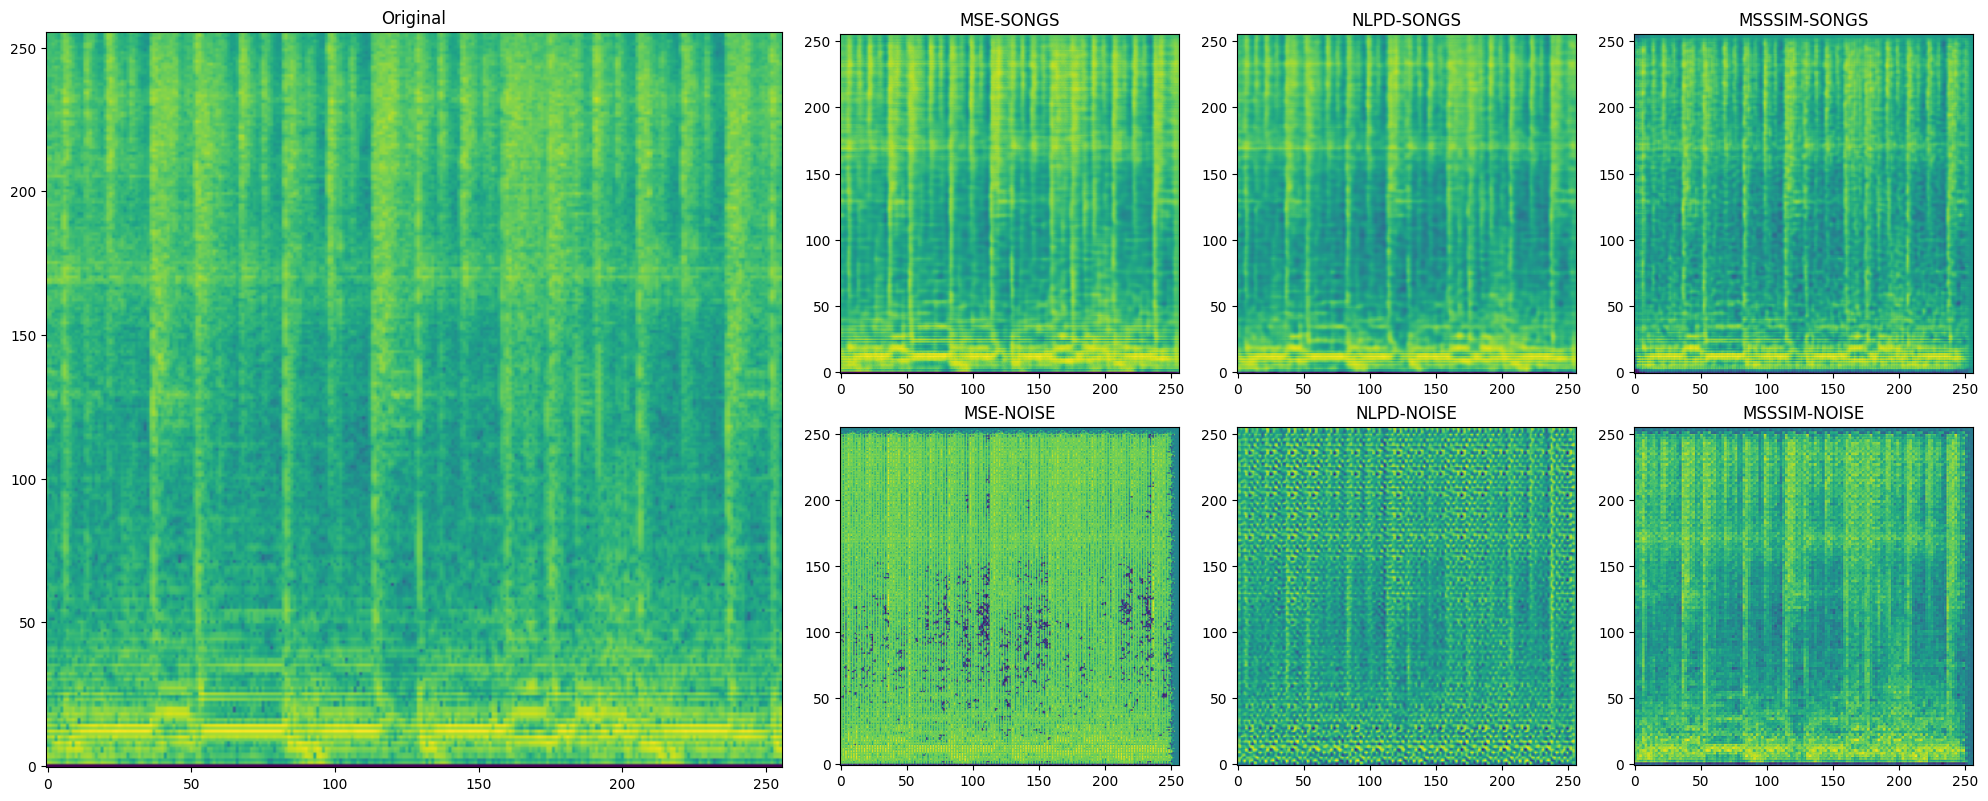

In [ ]:
fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(2, 5)

ax1 = fig.add_subplot(gs[:, 0:2])

ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[0, 3])
ax4 = fig.add_subplot(gs[0, 4])
ax5 = fig.add_subplot(gs[1, 2])
ax6 = fig.add_subplot(gs[1, 3])
ax7 = fig.add_subplot(gs[1, 4])

axes = (ax2, ax3, ax4, ax5, ax6, ax7)
ax1.imshow(example[indice_audio].detach().numpy(),origin='lower')
ax1.set_title("Original")

reformed = []
for imod in range(len(modelos)):
    mod = modelos[imod]
    mod.eval()
    with torch.no_grad():
        output = mod(example_adapt[indice_audio].unsqueeze(0).to("cpu"))
        output = output.squeeze(0).squeeze(0).cpu().numpy()
        reformed.append(output)
        axes[imod].imshow(output,origin='lower')
        axes[imod].set_title(order_models[imod])

plt.tight_layout()
plt.show()

Y a continuación se puede escuchar el audio original del archivo seleccionado y a continuación los audios reconstruidos.

In [ ]:
reconstruction = Reconstruction(example[indice_audio], maxi=metadata[0]["maximum"], mini=metadata[0]["minimum"])
original = Audio(reconstruction.detach().numpy(), rate=16000)
print("Original Audio")
display(original)

ind = 0
for reform in reformed:
    print("Reconstructed Audio:", order_models[ind]);ind+=1
    reconstruction = Reconstruction(torch.tensor(reform), maxi=metadata[0]["maximum"], mini=metadata[0]["minimum"])
    play_music = Audio(reconstruction.detach().numpy(), rate=16000)
    display(play_music)

Original Audio


Reconstructed Audio: MSE-SONGS


Reconstructed Audio: NLPD-SONGS


Reconstructed Audio: MSSSIM-SONGS


Reconstructed Audio: MSE-NOISE


Reconstructed Audio: NLPD-NOISE


Reconstructed Audio: MSSSIM-NOISE
